# **Установка библиотек**

In [1]:
!pip install -q gensim matplotlib seaborn scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from pathlib import Path
from gensim.models import Word2Vec
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Русский шрифт для графиков
plt.rcParams['font.family'] = 'DejaVu Sans'
print('Готово ✓')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 44.8 MB/s eta 0:00:00
Готово ✓


# **1. Загрузка размеченных текстов**

In [2]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import re

# ── ПУТИ ──────────────────────────────────────────────────────────
LABELED_DIR = Path('/content/drive/MyDrive/SFU 4/VKR/3. labeling/Словарная разметка/(FOR USE) После удаления одинаковых/labeled_clean')
LEMMA_DIR   = Path('/content/drive/MyDrive/SFU 4/VKR/1. processed/Lemma')
# ──────────────────────────────────────────────────────────────────

MIN_TOKENS = 10

def load_texts_from_folder(folder_path):
    sentences = []
    for fpath in Path(folder_path).glob('*.txt'):
        try:
            text = fpath.read_text(encoding='utf-8').strip()
            if len(text) < 5:
                continue
            # Убираем всё кроме кириллицы и пробелов
            text = re.sub(r'[^а-яА-ЯёЁ\s]', ' ', text)
            text = re.sub(r'\s+', ' ', text).strip()
            tokens = text.lower().split()
            # Только чисто кириллические токены длиннее 2 символов
            tokens = [t for t in tokens if t.isalpha() and len(t) > 2]
            if len(tokens) >= MIN_TOKENS:
                sentences.append(tokens)
        except:
            pass
    return sentences

# Depression и neutral — из размеченных папок
print('Загружаем depression и neutral...')
sentences_dep = load_texts_from_folder(LABELED_DIR / 'depression')
sentences_neu = load_texts_from_folder(LABELED_DIR / 'neutral')

# Anxiety — лемматизированные тексты из anxiety-папок напрямую
print('Загружаем anxiety...')
sentences_anx = []
for folder in ['reda_c', 'reda_p', 'tga_p']:
    folder_path = LEMMA_DIR / folder
    if folder_path.exists():
        loaded = load_texts_from_folder(folder_path)
        sentences_anx.extend(loaded)
        print(f'  {folder}: {len(loaded)} текстов')
    else:
        print(f'  ⚠️ не найдено: {folder_path}')

sentences_all = sentences_dep + sentences_anx + sentences_neu

print(f'\ndepression: {len(sentences_dep)} текстов')
print(f'anxiety:    {len(sentences_anx)} текстов')
print(f'neutral:    {len(sentences_neu)} текстов')
print(f'всего:      {len(sentences_all)} текстов')

Mounted at /content/drive
Загружаем depression и neutral...
Загружаем anxiety...
  reda_c: 1219 текстов
  reda_p: 64 текстов
  tga_p: 279 текстов

depression: 1630 текстов
anxiety:    1562 текстов
neutral:    2454 текстов
всего:      5646 текстов


In [3]:
# Фильтруем тексты короче 10 слов
MIN_TOKENS = 10

sentences_dep_f = [s for s in sentences_dep if len(s) >= MIN_TOKENS]
sentences_anx_f = [s for s in sentences_anx if len(s) >= MIN_TOKENS]
sentences_neu_f = [s for s in sentences_neu if len(s) >= MIN_TOKENS]
sentences_all_f = sentences_dep_f + sentences_anx_f + sentences_neu_f

print(f'После фильтрации (мин. {MIN_TOKENS} слов):')
print(f'depression: {len(sentences_dep_f)} текстов (было {len(sentences_dep)})')
print(f'anxiety:    {len(sentences_anx_f)} текстов (было {len(sentences_anx)})')
print(f'neutral:    {len(sentences_neu_f)} текстов (было {len(sentences_neu)})')
print(f'всего:      {len(sentences_all_f)} текстов')

После фильтрации (мин. 10 слов):
depression: 1630 текстов (было 1630)
anxiety:    1562 текстов (было 1562)
neutral:    2454 текстов (было 2454)
всего:      5646 текстов


👆🏼 Часть текстов после фильтрации оказалась слишком короткой — меньше 3 слов длиннее 2 символов. Это нормально для комментариев типа "да", "ок", "спасибо".
Разница: 8458 - 7346 = 1112 текстов отфильтровано. Это очень короткие тексты — для Word2Vec они бесполезны, модель не может извлечь контекст из 1-2 слов.

# **2. Обучение моделей Word2Vec**

In [4]:
W2V_PARAMS = dict(
    vector_size=200,
    window=5,
    min_count=3,
    workers=4,
    sg=1,
    epochs=15,
    seed=42
)

print('Обучаем модели...')

model_dep = Word2Vec(sentences_dep, **W2V_PARAMS)
print(f'depression: {len(model_dep.wv)} слов в словаре')

model_anx = Word2Vec(sentences_anx, **W2V_PARAMS)
print(f'anxiety:    {len(model_anx.wv)} слов в словаре')

model_neu = Word2Vec(sentences_neu, **W2V_PARAMS)
print(f'neutral:    {len(model_neu.wv)} слов в словаре')

model_all = Word2Vec(sentences_all, **W2V_PARAMS)
print(f'all:        {len(model_all.wv)} слов в словаре')


SAVE_DIR = Path('/content/drive/MyDrive/SFU 4/VKR/4. word2vec/models')
SAVE_DIR.mkdir(exist_ok=True)

model_dep.save(str(SAVE_DIR / 'w2v_depression.model'))
model_anx.save(str(SAVE_DIR / 'w2v_anxiety.model'))
model_neu.save(str(SAVE_DIR / 'w2v_neutral.model'))
model_all.save(str(SAVE_DIR / 'w2v_all.model'))

print('\nМодели сохранены ✓')

Обучаем модели...
depression: 4797 слов в словаре
anxiety:    4269 слов в словаре
neutral:    4416 слов в словаре
all:        8992 слов в словаре

Модели сохранены ✓


# **3. Семантические соседи ключевых слов**

In [5]:
MODELS = {
    'depression': model_dep,
    'anxiety': model_anx,
    'neutral': model_neu
}

COLORS = {
    'depression': '#e74c3c',
    'anxiety': '#3498db',
    'neutral': '#95a5a6'
}


def get_neighbors(word, model, topn=10):
    """Возвращает топ-N ближайших слов"""
    try:
        return model.wv.most_similar(word, topn=topn)
    except KeyError:
        return None


def compare_word(word, topn=10):

    print('\n' + '═'*60)
    print(f'  Слово: «{word}»')
    print('═'*60)

    results = {}

    for label, model in MODELS.items():

        neighbors = get_neighbors(word, model, topn)

        if neighbors:

            results[label] = neighbors
            words_str = ', '.join([f'{w}({s:.2f})' for w, s in neighbors[:5]])
            print(f'  {label:<12}: {words_str}')

        else:

            print(f'  {label:<12}: ⚠️ слово не в словаре')

    return results


KEY_WORDS = [
    'депрессия',
    'тревога',
    'страх',
    'одиночество',
    'помощь',
    'лечение',
    'чувство',
    'жизнь',
    'плохо'
]


all_results = {}

for word in KEY_WORDS:
    all_results[word] = compare_word(word)


════════════════════════════════════════════════════════════
  Слово: «депрессия»
════════════════════════════════════════════════════════════
  depression  : исключать(0.64), динамика(0.63), второстепенный(0.62), униполярный(0.62), неочевидный(0.62)
  anxiety     : низкий(0.72), показатель(0.71), опросник(0.71), склонность(0.71), доход(0.70)
  neutral     : злость(0.72), самообвинение(0.69), руминировать(0.69), потеря(0.66), энергия(0.66)

════════════════════════════════════════════════════════════
  Слово: «тревога»
════════════════════════════════════════════════════════════
  depression  : лихой(0.67), роберт(0.64), свобода(0.62), логический(0.61), горячо(0.61)
  anxiety     : неопределённость(0.63), шкала(0.62), прокрастинация(0.62), аллергия(0.61), острый(0.60)
  neutral     : снижение(0.85), техника(0.84), визуализация(0.83), подробный(0.78), симптом(0.78)

════════════════════════════════════════════════════════════
  Слово: «страх»
═══════════════════════════════════════════

# **Таблица соседей**

In [6]:
def neighbors_table(word, topn=10):

    rows = []
    max_len = 0
    cols = {}

    for label, model in MODELS.items():

        neighbors = get_neighbors(word, model, topn)

        if neighbors:
            cols[label] = [f'{w} ({s:.3f})' for w, s in neighbors]
            max_len = max(max_len, len(neighbors))
        else:
            cols[label] = ['—'] * topn

    df_table = pd.DataFrame(cols)
    df_table.index = range(1, len(df_table)+1)
    df_table.index.name = 'Ранг'

    return df_table


with pd.ExcelWriter('/content/drive/MyDrive/SFU 4/VKR/4. word2vec/semantic_neighbors.xlsx', engine='openpyxl') as writer:

    for word in KEY_WORDS:

        try:
            t = neighbors_table(word)
            t.to_excel(writer, sheet_name=word[:31])

        except Exception:
            pass


print('Таблицы соседей сохранены: semantic_neighbors.xlsx')
print('Каждое слово — отдельный лист в Excel')

print('\nПример — слово «тревога»:')
print(neighbors_table('тревога'))

Таблицы соседей сохранены: semantic_neighbors.xlsx
Каждое слово — отдельный лист в Excel

Пример — слово «тревога»:
                 depression                   anxiety                 neutral
Ранг                                                                         
1             лихой (0.672)  неопределённость (0.635)        снижение (0.849)
2            роберт (0.642)             шкала (0.622)         техника (0.842)
3           свобода (0.615)    прокрастинация (0.615)    визуализация (0.825)
4        логический (0.612)          аллергия (0.609)       подробный (0.781)
5            горячо (0.608)            острый (0.599)         симптом (0.778)
6         выступать (0.598)        совладаний (0.598)            вина (0.777)
7           эрекция (0.579)     гиперконтроль (0.594)  функциональный (0.767)
8             масса (0.579)        ипохондрия (0.587)         канеман (0.766)
9         разбирать (0.570)         связанный (0.585)      упражнение (0.761)
10    подавленность (0.564

# **4. Уникальные соседи классов**

In [7]:
print('═══ Уникальные семантические соседи по классам ═══\n')

unique_results = []

for word in KEY_WORDS:

    neighbors_by_class = {}

    for label, model in MODELS.items():

        n = get_neighbors(word, model, topn=20)

        if n:
            neighbors_by_class[label] = {w for w, _ in n}

    if len(neighbors_by_class) < 2:
        continue

    print(f'«{word}»:')

    for label in neighbors_by_class:

        others = set()

        for other_label, other_words in neighbors_by_class.items():
            if other_label != label:
                others |= other_words

        unique = neighbors_by_class[label] - others

        if unique:

            print(f'  {label}: {", ".join(sorted(unique))}')

            for w in unique:
                unique_results.append({
                    'keyword': word,
                    'class': label,
                    'unique_neighbor': w
                })

    print()


pd.DataFrame(unique_results).to_csv(
    '/content/drive/MyDrive/SFU 4/VKR/4. word2vec/unique_semantic_markers.csv',
    index=False,
    encoding='utf-8-sig'
)

print('Сохранено: unique_semantic_markers.csv')

═══ Уникальные семантические соседи по классам ═══

«депрессия»:
  depression: бездействие, второстепенный, вызывающий, грипп, динамика, зазеркалье, затрагивать, исключать, недуг, неочевидный, нетипичный, описывать, осложнять, последующий, похоже, психоз, социофобия, специфика, униполярный, утверждать
  anxiety: апатия, больной, болячка, галлюцинация, доход, логично, макросоциальный, низкий, опросник, пограничный, подверженный, показатель, психотический, учёт, шизофрения, шкала, штука, язвенный
  neutral: ведро, влияние, злость, изменение, кризис, локус, направить, подробный, потеря, предыдущий, признак, продуктивный, самообвинение, служить, справляться, телесный, тревожный, энергия

«тревога»:
  depression: высокий, выступать, горячо, качественно, лихой, логический, масса, подавленность, показатель, прогресс, прятаться, разбирать, роберт, свобода, сводить, стандарт, стрессоустойчивость, угроза, эрекция
  anxiety: аллергия, бек, гиперконтроль, глава, гтр, домен, ипохондрия, карен, криз

# **5. Аналогии Word2Vec**

In [8]:
def safe_analogy(model, positive, negative, topn=5):

    try:
        return model.wv.most_similar(
            positive=positive,
            negative=negative,
            topn=topn
        )

    except KeyError as e:
        return f'Слово не в словаре: {e}'


print('═══ Семантические аналогии ═══\n')

print('Модель ДЕПРЕССИЯ:')

print(
    '  депрессия + помощь =',
    safe_analogy(model_dep, ['депрессия', 'помощь'], [], 5)
)

print(
    '  грусть - тоска =',
    safe_analogy(model_dep, ['грусть'], ['тоска'], 5)
)


print('\nМодель ТРЕВОГА:')

print(
    '  тревога + контроль =',
    safe_analogy(model_anx, ['тревога', 'контроль'], [], 5)
)

print(
    '  страх - паника =',
    safe_analogy(model_anx, ['страх'], ['паника'], 5)
)

═══ Семантические аналогии ═══

Модель ДЕПРЕССИЯ:
  депрессия + помощь = [('пожизненный', 0.7300339937210083), ('заинтересованный', 0.6993098258972168), ('сирена', 0.6916093230247498), ('специфика', 0.6865246891975403), ('имхо', 0.6840797662734985)]
  грусть - тоска = [('право', 0.4337826073169708), ('основание', 0.3273317813873291), ('направить', 0.32311007380485535), ('терапевт', 0.30405566096305847), ('подходить', 0.2966322600841522)]

Модель ТРЕВОГА:
  тревога + контроль = [('уравнение', 0.8000120520591736), ('гиперконтроль', 0.7924159169197083), ('вызывающий', 0.7775903344154358), ('домен', 0.7733255624771118), ('лишать', 0.7644144296646118)]
  страх - паника = [('возможность', 0.23534749448299408), ('получиться', 0.21991847455501556), ('идея', 0.1951417773962021), ('искать', 0.18860319256782532), ('найти', 0.18665342032909393)]


# **Косинусное сходство слов**

In [9]:
print('\n═══ Косинусное сходство пар слов ═══')

pairs = [
    ('депрессия', 'тревога'),
    ('страх', 'тоска'),
    ('одиночество', 'изоляция'),
    ('помощь', 'лечение')
]

print(f'{"Пара":<35} {"DEP":>8} {"ANX":>8} {"NEU":>8}')
print('─' * 62)

for w1, w2 in pairs:

    row = f'{w1} — {w2}'
    scores = []

    for model in [model_dep, model_anx, model_neu]:

        try:
            s = model.wv.similarity(w1, w2)
            scores.append(f'{s:.3f}')

        except KeyError:
            scores.append('  —  ')

    print(f'{row:<35} {scores[0]:>8} {scores[1]:>8} {scores[2]:>8}')


═══ Косинусное сходство пар слов ═══
Пара                                     DEP      ANX      NEU
──────────────────────────────────────────────────────────────
депрессия — тревога                    0.237    0.328    0.527
страх — тоска                          0.690    0.463      —  
одиночество — изоляция                 0.478      —        —  
помощь — лечение                       0.317    0.352      —  


# **6. t-SNE — семантическая карта корпуса**

In [10]:
def get_top_words(sentences, n=80):
    from collections import Counter
    counter = Counter(w for sent in sentences for w in sent)
    return [w for w, _ in counter.most_common(n)]


top_dep = get_top_words(sentences_dep, 80)
top_anx = get_top_words(sentences_anx, 80)
top_neu = get_top_words(sentences_neu, 80)


ONTOLOGY_WORDS = [
    'депрессия','тревога','страх','апатия','паника',
    'одиночество','безнадежность','усталость','бессонница',
    'тоска','грусть','беспокойство','напряжение','раздражение'
]


words_to_plot = list(
    set(
        top_dep[:50] +
        top_anx[:50] +
        top_neu[:30] +
        ONTOLOGY_WORDS
    )
)

words_to_plot = [w for w in words_to_plot if w in model_all.wv]

print(f'Слов для визуализации: {len(words_to_plot)}')


vectors = np.array([model_all.wv[w] for w in words_to_plot])


print('Вычисляем t-SNE...')

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=min(30, len(words_to_plot)//3),
    n_iter=1000
)

coords = tsne.fit_transform(vectors)

print('Готово ✓')

Слов для визуализации: 73
Вычисляем t-SNE...
Готово ✓


# **Построение t-SNE графика**

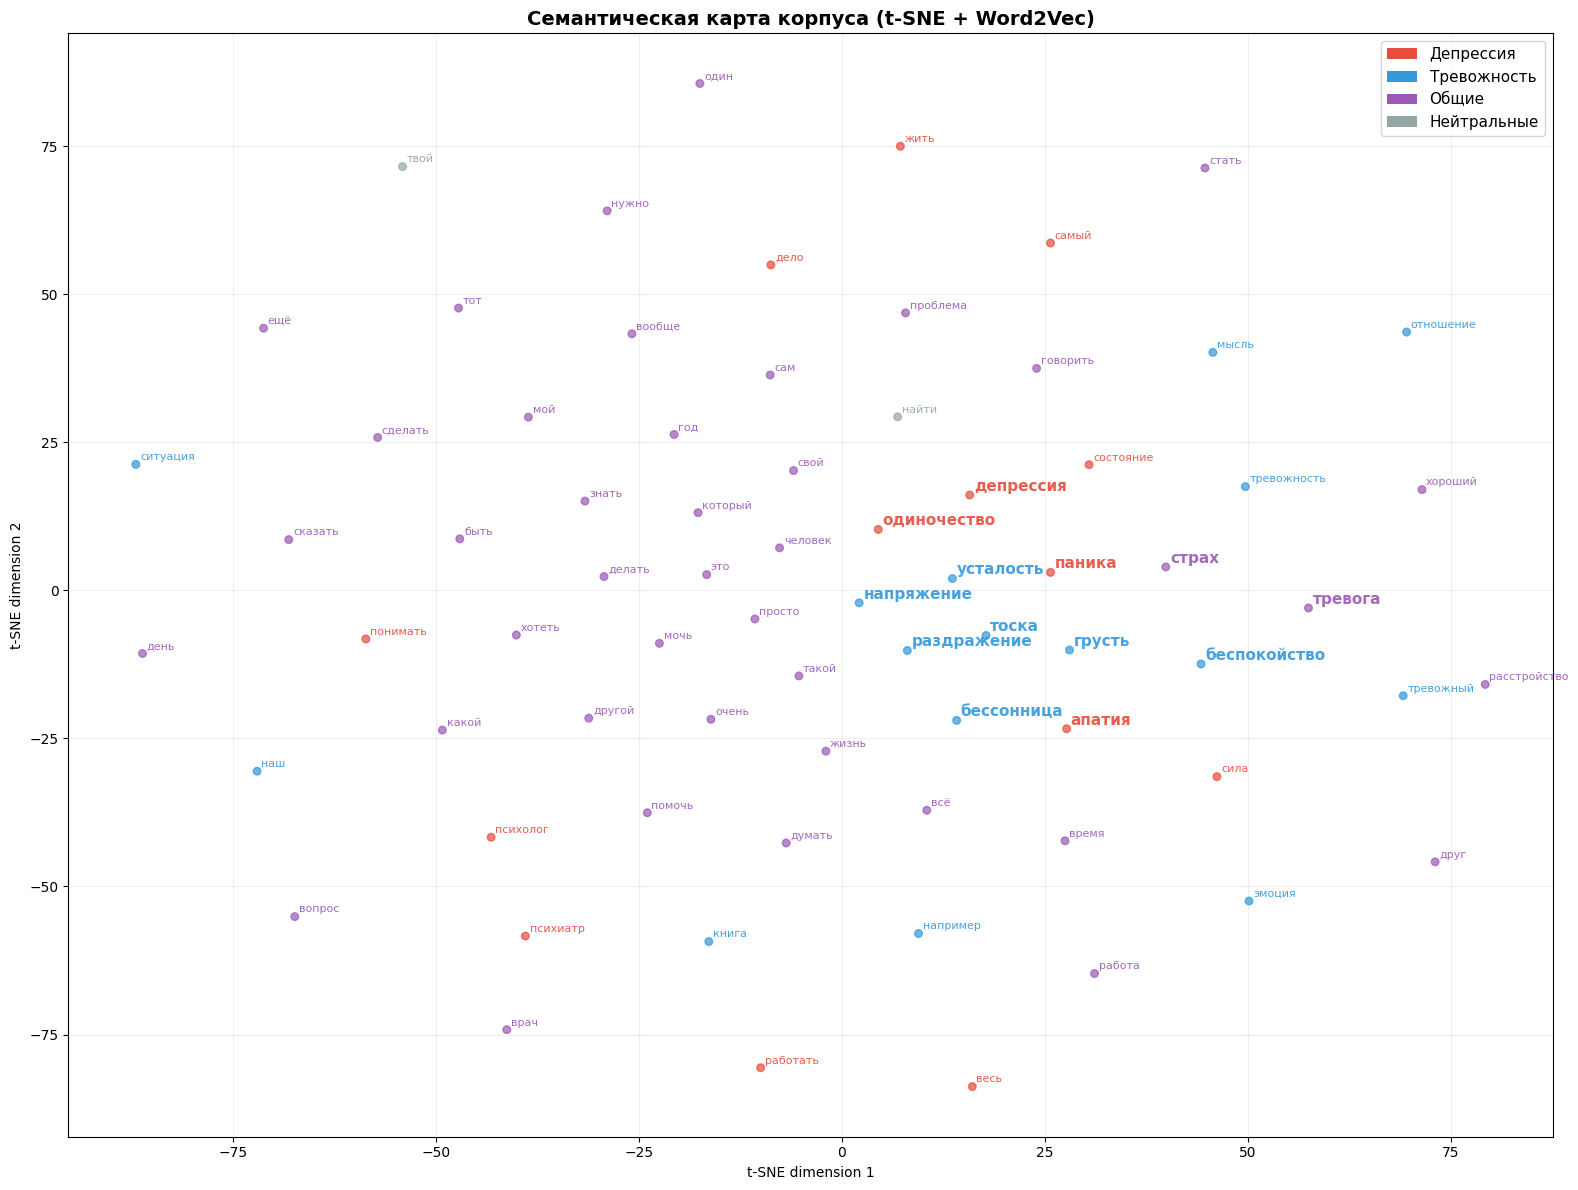

Сохранено: tsne_semantic_map.png


In [12]:
dep_set = set(top_dep[:50]) | set(ONTOLOGY_WORDS[:7])
anx_set = set(top_anx[:50]) | set(ONTOLOGY_WORDS[7:])


def word_color(word):

    if word in dep_set and word not in anx_set:
        return '#e74c3c'

    if word in anx_set and word not in dep_set:
        return '#3498db'

    if word in dep_set and word in anx_set:
        return '#9b59b6'

    return '#95a5a6'


point_colors = [word_color(w) for w in words_to_plot]


fig, ax = plt.subplots(figsize=(16, 12))

ax.scatter(
    coords[:,0],
    coords[:,1],
    c=point_colors,
    s=30,
    alpha=0.7,
    zorder=2
)


for i, word in enumerate(words_to_plot):

    fontsize = 11 if word in ONTOLOGY_WORDS else 8
    fontweight = 'bold' if word in ONTOLOGY_WORDS else 'normal'

    ax.annotate(
        word,
        (coords[i,0], coords[i,1]),
        fontsize=fontsize,
        fontweight=fontweight,
        xytext=(3,3),
        textcoords='offset points',
        color=word_color(word),
        alpha=0.9
    )


from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor='#e74c3c', label='Депрессия'),
    Patch(facecolor='#3498db', label='Тревожность'),
    Patch(facecolor='#9b59b6', label='Общие'),
    Patch(facecolor='#95a5a6', label='Нейтральные')
]

ax.legend(handles=legend_elements, loc='upper right', fontsize=11)

ax.set_title(
    'Семантическая карта корпуса (t-SNE + Word2Vec)',
    fontsize=14,
    fontweight='bold'
)

ax.set_xlabel('t-SNE dimension 1')
ax.set_ylabel('t-SNE dimension 2')

ax.grid(True, alpha=0.2)

plt.tight_layout()

plt.savefig(
    '/content/drive/MyDrive/SFU 4/VKR/4. word2vec/pngs/tsne_semantic_map.png',
    dpi=200,
    bbox_inches='tight'
)

plt.show()

print('Сохранено: tsne_semantic_map.png')

# **7. Графики соседей слова**

In [13]:
def plot_word_neighbors(word, topn=10):

    fig, axes = plt.subplots(1,3, figsize=(16,5))

    for ax, (label, model) in zip(axes, MODELS.items()):

        neighbors = get_neighbors(word, model, topn)

        if not neighbors:

            ax.text(
                0.5,
                0.5,
                f'«{word}»\nне в словаре',
                ha='center',
                va='center',
                transform=ax.transAxes
            )

            ax.set_title(label)
            continue


        words_n = [w for w,_ in neighbors]
        scores = [s for _,s in neighbors]


        bars = ax.barh(
            range(len(words_n)),
            scores,
            color=COLORS[label],
            alpha=0.8,
            edgecolor='white'
        )


        ax.set_yticks(range(len(words_n)))
        ax.set_yticklabels(words_n, fontsize=10)

        ax.set_xlim(0,1)

        ax.set_xlabel('Косинусное сходство')

        ax.set_title(
            f'{label}\n(топ-{topn} соседей «{word}»)',
            fontweight='bold'
        )

        ax.invert_yaxis()


        for bar, score in zip(bars, scores):

            ax.text(
                score + 0.01,
                bar.get_y() + bar.get_height()/2,
                f'{score:.3f}',
                va='center',
                fontsize=8
            )


    plt.suptitle(
        f'Семантические соседи слова «{word}» по классам',
        fontsize=13,
        fontweight='bold'
    )

    plt.tight_layout()

    plt.savefig(
        f'/content/drive/MyDrive/SFU 4/VKR/4. word2vec/pngs/neighbors_{word}.png',
        dpi=150,
        bbox_inches='tight'
    )

    plt.show()

# **Построение графиков**

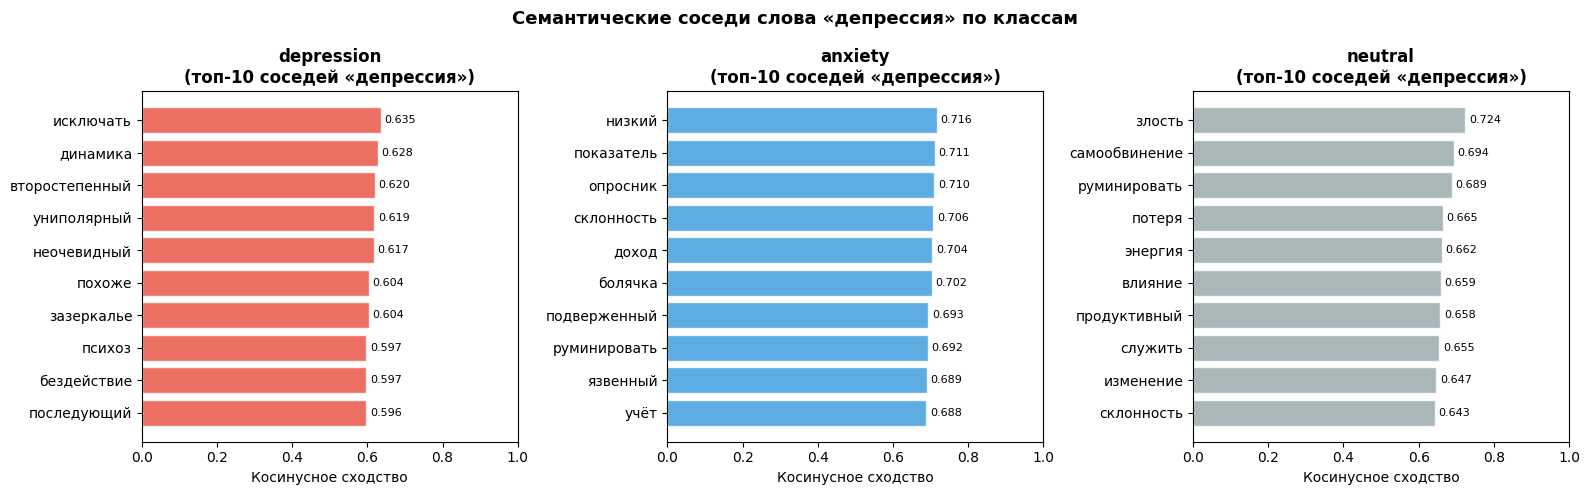

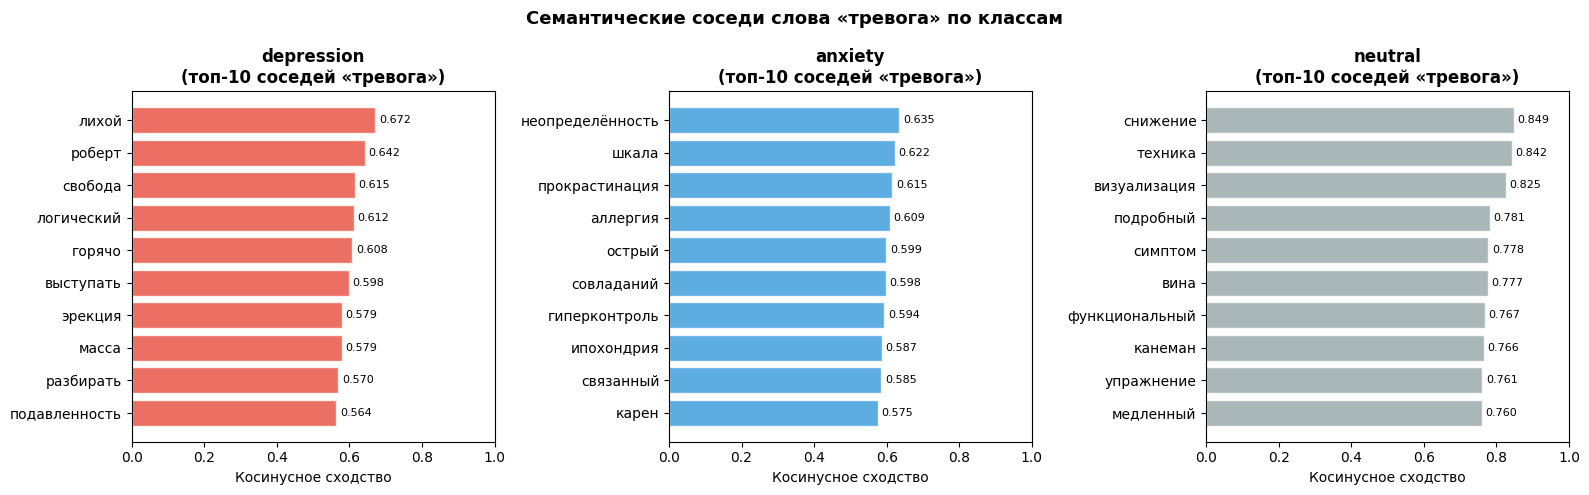

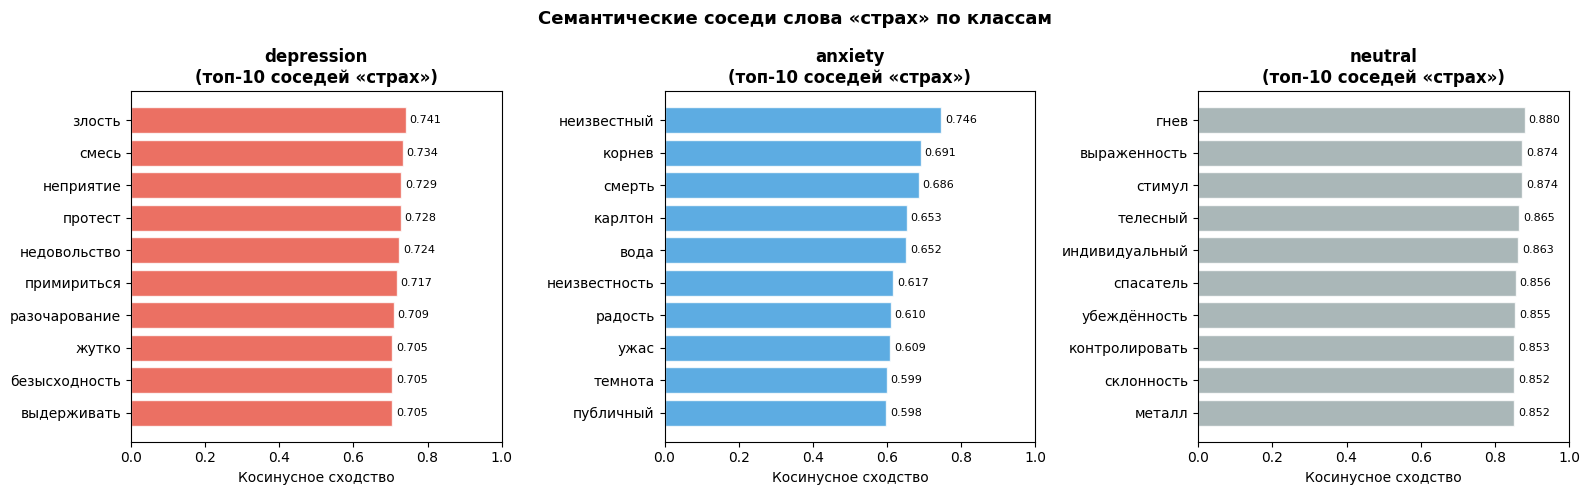

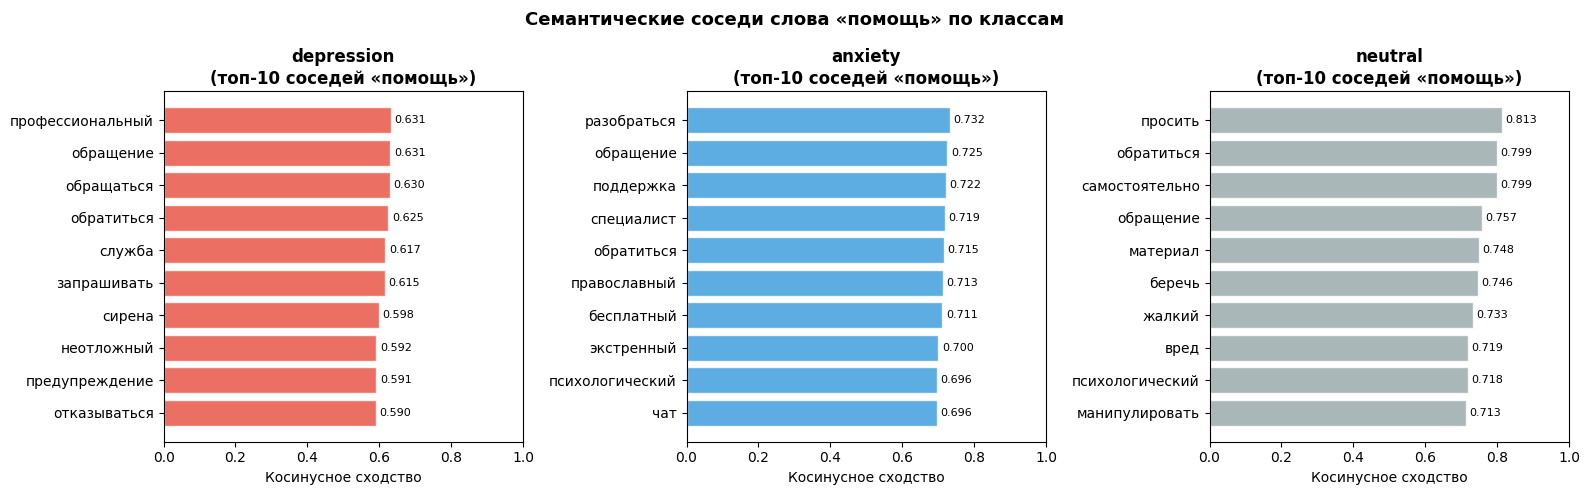

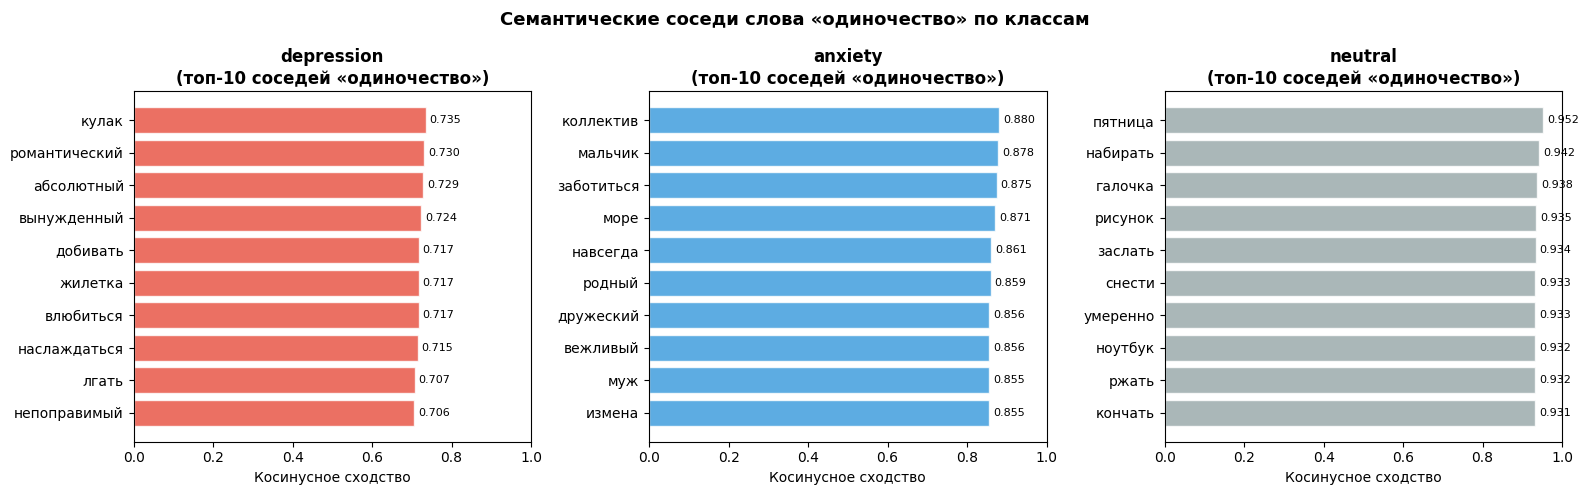

In [14]:
for word in ['депрессия','тревога','страх','помощь','одиночество']:
    plot_word_neighbors(word)

# **8. Финальная таблица для ВКР**

In [15]:
import openpyxl
from openpyxl.styles import Font, PatternFill
from openpyxl.utils import get_column_letter

wb = openpyxl.Workbook()
ws = wb.active
ws.title = 'Семантические поля'

fill_dep = PatternFill(start_color='FFCCCC', fill_type='solid')
fill_anx = PatternFill(start_color='CCE5FF', fill_type='solid')
fill_neu = PatternFill(start_color='E0E0E0', fill_type='solid')
fills = {
    'depression': fill_dep,
    'anxiety': fill_anx,
    'neutral': fill_neu
}

row = 1

for word in KEY_WORDS:
    ws.cell(row, 1, f'Слово: «{word}»').font = Font(bold=True, size=12)
    ws.merge_cells(start_row=row, start_column=1, end_row=row, end_column=6)
    row += 1

    # Заголовки для трех категорий (depression, anxiety, neutral)
    for col, (label, fill) in enumerate(fills.items(), start=1):
        # Объединяем две ячейки (Слово и Сходство) для заголовка категории
        ws.merge_cells(start_row=row, start_column=col*2-1, end_row=row, end_column=col*2)
        header_cell = ws.cell(row, col*2-1, label.lower())  # или label.capitalize()
        header_cell.fill = fill
        header_cell.font = Font(bold=True, size=11)

    row += 1

    # Подзаголовки "Слово" и "Сходство"
    for col, (label, fill) in enumerate(fills.items(), start=1):
        c1 = ws.cell(row, col*2-1, 'Слово')
        c2 = ws.cell(row, col*2, 'Сходство')
        for c in [c1, c2]:
            c.fill = fill
            c.font = Font(bold=True)
    row += 1

    neighbors_data = {}
    for label, model in MODELS.items():
        n = get_neighbors(word, model, 10)
        neighbors_data[label] = n if n else [('—', 0)] * 10

    for i in range(10):
        for col, label in enumerate(['depression', 'anxiety', 'neutral'], start=1):
            if i < len(neighbors_data[label]):
                w, s = neighbors_data[label][i]
                ws.cell(row, col*2-1, w)
                ws.cell(row, col*2, round(s, 3))
        row += 1
    row += 1

# Установка ширины колонок
for i in range(1, ws.max_column + 1):
    ws.column_dimensions[get_column_letter(i)].width = 18

wb.save('/content/drive/MyDrive/SFU 4/VKR/4. word2vec/semantic_fields_VKR.xlsx')
print('Сохранено: semantic_fields_VKR.xlsx')

Сохранено: semantic_fields_VKR.xlsx
